# Visualize predictions

In [73]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

modality_map = {
    "0000": "T1C",
    "0001": "T1N",
    "0002": "T2F",
    "0003": "T2W"
}

def to_regions_base(predictions, wt_labels, tc_labels, et_labels):
    # Initialize binary segmentation maps
    wt_segmentation = np.zeros_like(predictions, dtype=np.uint8)  # Whole Tumor
    tc_segmentation = np.zeros_like(predictions, dtype=np.uint8)  # Tumor Core
    et_segmentation = np.zeros_like(predictions, dtype=np.uint8)  # Enhancing Tumor

    # Create binary segmentation for Whole Tumor
    wt_segmentation[np.isin(predictions, wt_labels)] = 1

    # Create binary segmentation for Tumor Core
    tc_segmentation[np.isin(predictions, tc_labels)] = 1

    # Create binary segmentation for Enhancing Tumor
    et_segmentation[np.isin(predictions, et_labels)] = 1

    return wt_segmentation, tc_segmentation, et_segmentation

def to_regions_v1(predictions):
    return to_regions_base(
        predictions=predictions,
        wt_labels=[1, 2, 3, 4],  # Whole Tumor labels
        tc_labels=[1, 3, 4],     # Tumor Core labels
        et_labels=[4]            # Active Tumor label
    )

def to_regions_v2(predictions):
    return to_regions_base(
        predictions=predictions,
        wt_labels=[1, 2, 3],  # Whole Tumor labels
        tc_labels=[1, 3],     # Tumor Core labels
        et_labels=[3]         # Enhancing Tumor label
    )

def plot_color_code():
    fig, axs = plt.subplots(1, 2, figsize=(10,5))

    axs[0].imshow(np.array([
        [0,0,0],
        [1,1,1],
        [2,2,2],
        [3,3,3]
    ]).T)
    axs[0].set_xticks([0,1,2,3])
    axs[0].set_title("Labels for integer map of Segresnet and TverskyBCE")

    axs[1].imshow(np.array([
        [0,0,0],
        [1,1,1],
        [2,2,2],
        [3,3,3],
        [4,4,4]
    ]).T)
    axs[1].set_title("Labels for integer map of nnUNetv1 Pnev")

(182, 218, 182) (182, 218, 182) (182, 218, 182) (182, 218, 182)
[0. 1. 2. 3.] [0. 1. 2. 3.] [0. 1. 2. 3. 4.]


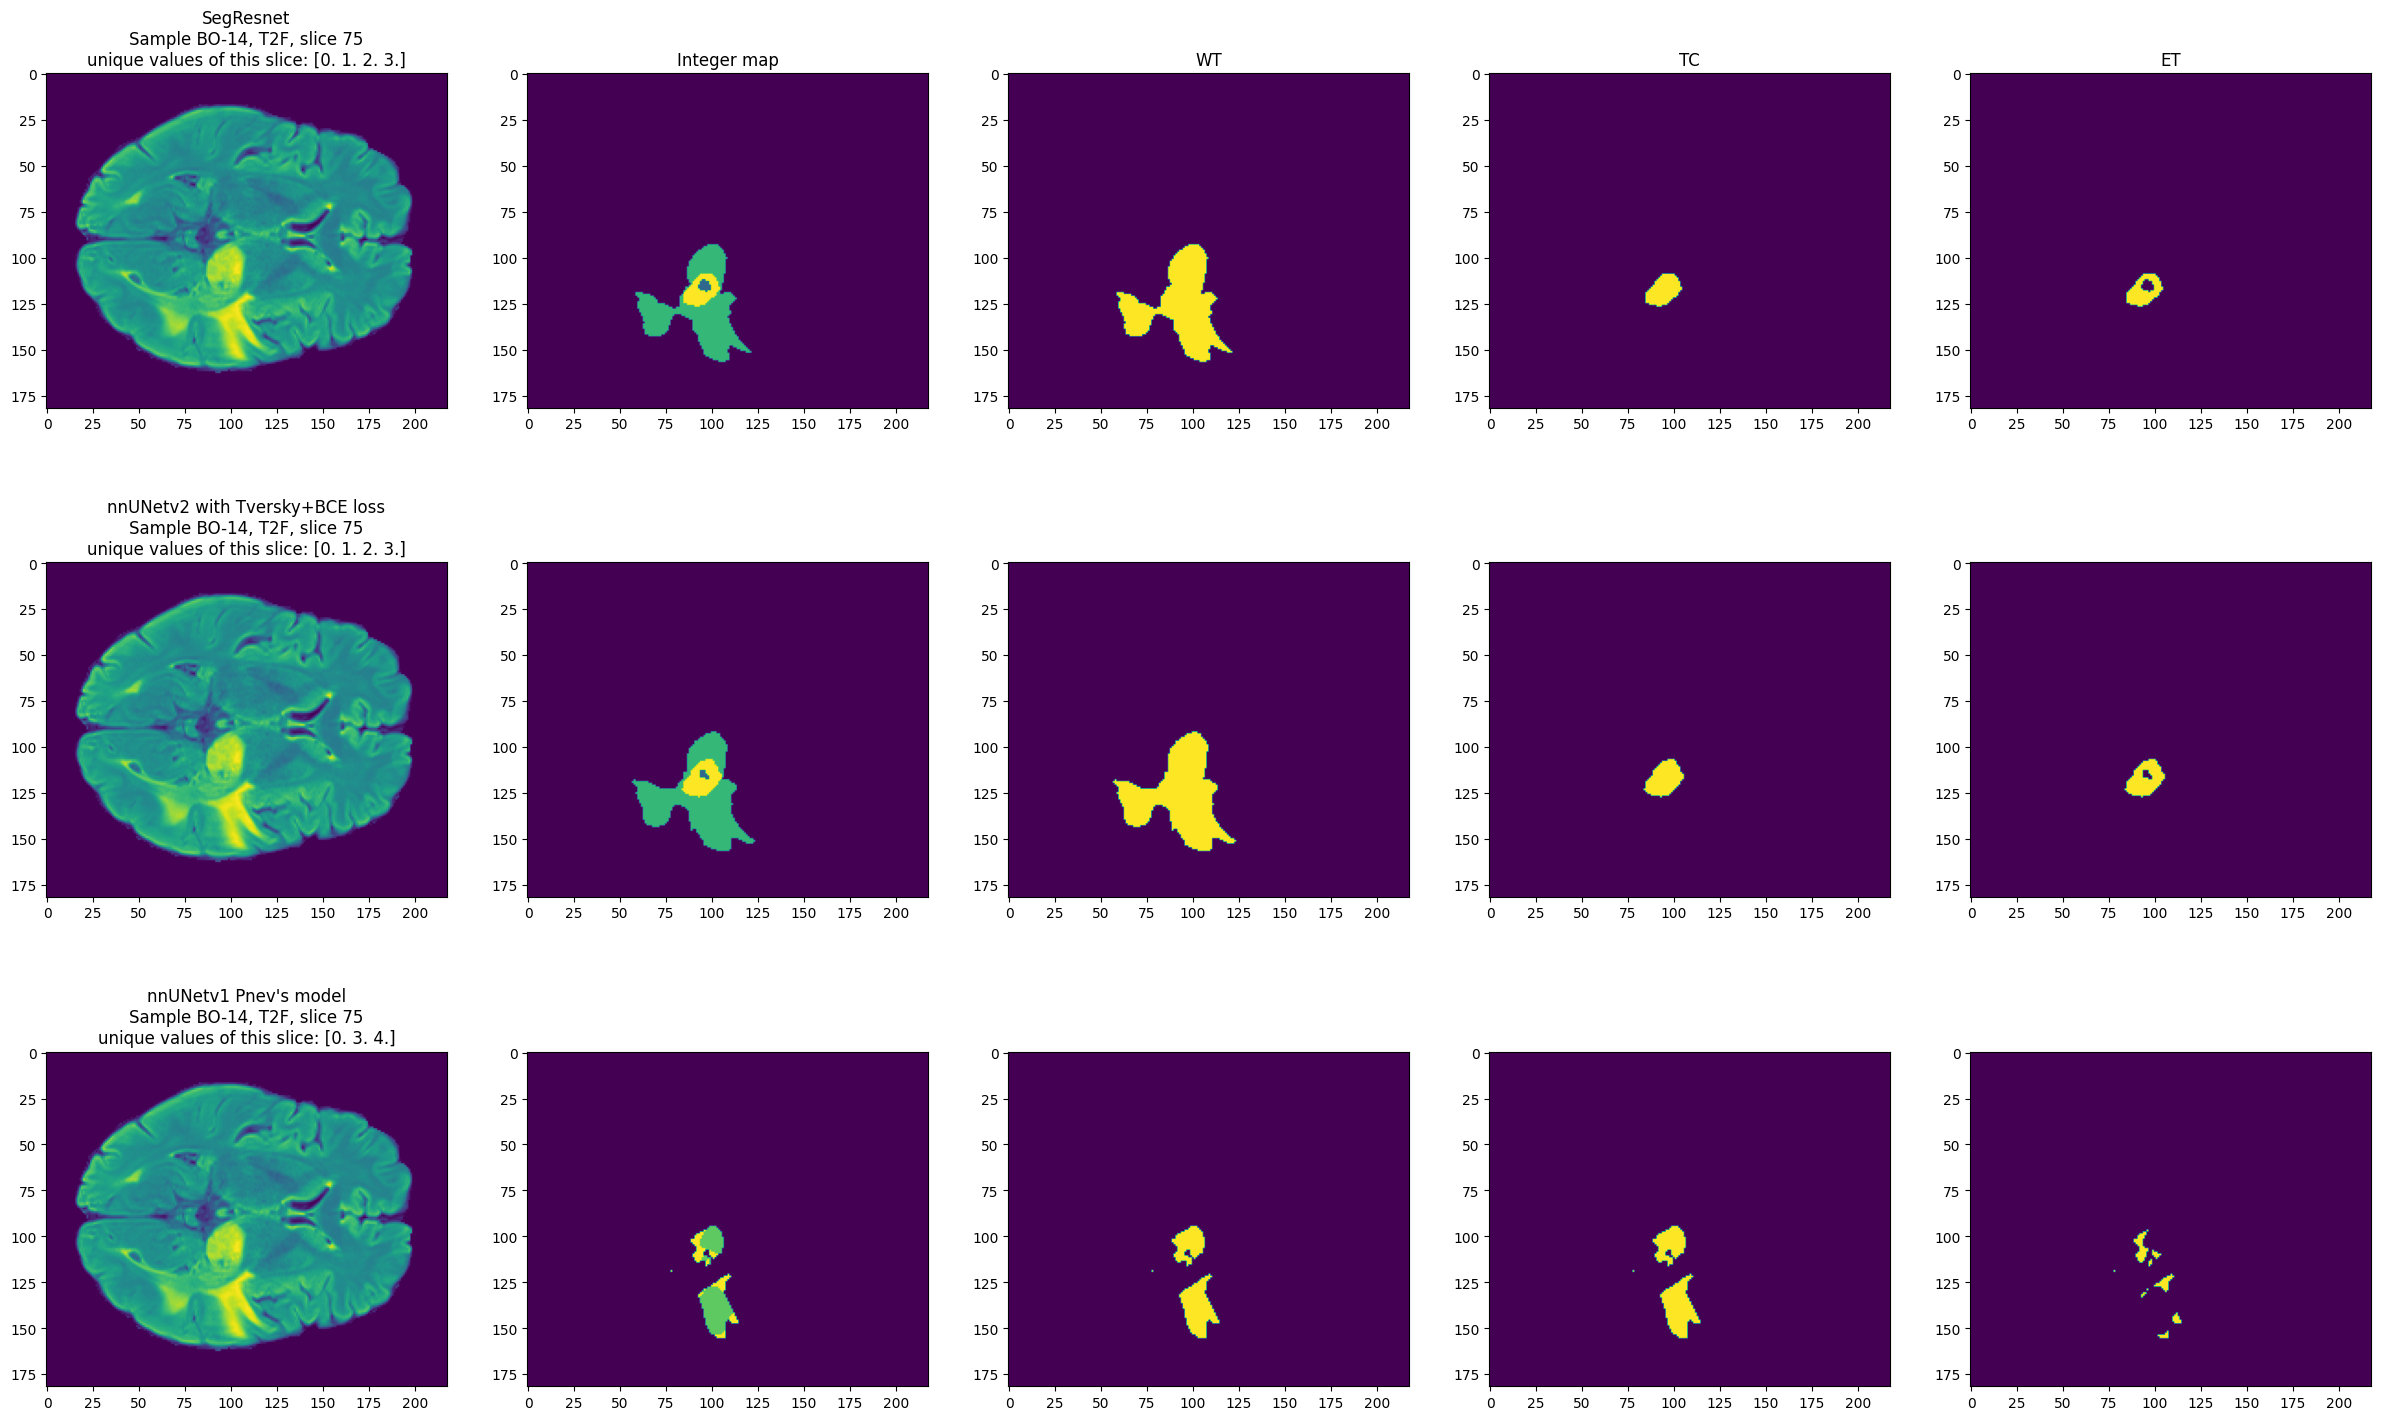

In [90]:
sample_id = "BO-14"
slice_idx = 75
modality_code = "0002"
modality_text = modality_map.get(modality_code)

img_path  = f"/media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/{sample_id}_{modality_code}.nii.gz"
seg_path1 = f"/media/storage/luu/nnUNet_preds/BraTS_segresnet/{sample_id}.nii.gz"
seg_path2 = f"/media/storage/luu/nnUNet_preds/BraTS_tverskybce/{sample_id}.nii.gz"
seg_path3 = f"/media/storage/luu/nnUNet_preds/Pnev_model/{sample_id}.nii.gz"

# Load original image
img       = nib.load(img_path).get_fdata()

# Load predictions from models
seg1      = nib.load(seg_path1).get_fdata()
seg2      = nib.load(seg_path2).get_fdata()
seg3      = nib.load(seg_path3).get_fdata()

# Convert from integer map to binary segmentation of tumor sub-regions
regions1 = to_regions_v2(seg1)
regions2 = to_regions_v2(seg2)
regions3 = to_regions_v2(seg3)

print(img.shape, seg1.shape, seg2.shape, seg3.shape)
print(np.unique(seg1), np.unique(seg2), np.unique(seg3))

slice_unique_values1 = np.unique(seg1[...,slice_idx])
slice_unique_values2 = np.unique(seg2[...,slice_idx])
slice_unique_values3 = np.unique(seg3[...,slice_idx])

# ----------
# Visualize
fig, axs = plt.subplots(3,5, figsize=(5*6, 3*6))

# General
axs[0,1].set_title("Integer map")
axs[0,2].set_title("WT")
axs[0,3].set_title("TC")
axs[0,4].set_title("ET")

# SegResNet

axs[0,0].imshow(img[..., slice_idx])
axs[0,0].set_title(f"SegResnet\nSample {sample_id}, {modality_text}, slice {slice_idx}\nunique values of this slice: {slice_unique_values1}")

axs[0,1].imshow(seg1[..., slice_idx])
axs[0,2].imshow(regions1[0][..., slice_idx])
axs[0,3].imshow(regions1[1][..., slice_idx])
axs[0,4].imshow(regions1[2][..., slice_idx])


# nnUNet with Tversky + BCE loss
regions2 = to_regions_v2(seg2)
axs[1,0].imshow(img[..., slice_idx])
axs[1,0].set_title(f"nnUNetv2 with Tversky+BCE loss\nSample {sample_id}, {modality_text}, slice {slice_idx}\nunique values of this slice: {slice_unique_values2}")

axs[1,1].imshow(seg2[..., slice_idx])
axs[1,2].imshow(regions2[0][..., slice_idx])
axs[1,3].imshow(regions2[1][..., slice_idx])
axs[1,4].imshow(regions2[2][..., slice_idx])


# nnUNetv1 Pnev's model
regions3 = to_regions_v1(seg3)
axs[2,0].imshow(img[..., slice_idx])
axs[2,0].set_title(f"nnUNetv1 Pnev's model\nSample {sample_id}, {modality_text}, slice {slice_idx}\nunique values of this slice: {slice_unique_values3}")

axs[2,1].imshow(seg3[..., slice_idx])
axs[2,2].imshow(regions3[0][..., slice_idx])
axs[2,3].imshow(regions3[1][..., slice_idx])
axs[2,4].imshow(regions3[2][..., slice_idx])

In [91]:
img_fp = f"/media/storage/luu/inferences_comparison/compare_{sample_id}.png"
print(f"Saving to {img_fp}")
fig.tight_layout()
fig.savefig(img_fp, format="png")

Saving to /media/storage/luu/inferences_comparison/compare_BO-14.png


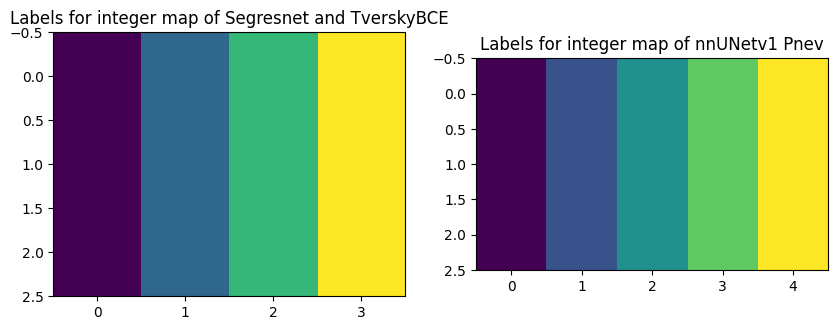

In [32]:
plot_color_code()

# Copy files to nnUNet_raw folder

In [1]:
import os
import shutil

imagesTr = "/media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr"
labelsTr = "/media/storage/luu/nnUNet_raw/Dataset444_Reg/labelsTr"

modality_map = {
    "t1ce" : "0000",
    "t1"   : "0001",
    "flair": "0002",
    "t2"   : "0003",
}

In [13]:
def copy_files(source_dir):
    # Get all filepaths from source dir
    fns = [fn for fn in os.listdir(source_dir) if 'brain' in fn]
    assert len(fns) == 5, f"{fns}"
    fps = [os.path.join(source_dir, fn) for fn in fns]

    # Get new filepaths and copy file from old filepaths to new filepaths
    for old_fp in fps:
        components = old_fp.split("/")
        id_ = components[-2]
        old_fn = components[-1]
        if "mask" in old_fn:
            new_fn = f"{id_}.nii.gz"
            new_fp = os.path.join(labelsTr, new_fn)
        else:
            modality_text = old_fn.split("_")[0]
            modality_code = modality_map[modality_text]
            new_fn = f"{id_}_{modality_code}.nii.gz"
            new_fp = os.path.join(imagesTr, new_fn)
        
        if os.path.isfile(new_fp):
            print(f"File exist at {new_fp}. Do not copy")
        else:
            print(f"Copying from {old_fp} > {new_fp}")
            shutil.copyfile(old_fp, new_fp)

In [ ]:
root_dir = "/media/storage/luu/reg_data/uz"
subdirs = sorted(os.listdir(root_dir))

for subdir in subdirs:
    # BO is a nested folder
    if subdir == "BO":
        lv2_subdirs = sorted(os.listdir(os.path.join(root_dir, subdir)))
        for lv2_subdir in lv2_subdirs:
            source_dir_to_copy = os.path.join(root_dir, subdir, lv2_subdir)
            print(f"Copying dir {source_dir_to_copy}")
            copy_files(source_dir=source_dir_to_copy)
            print("")
    else:
        source_dir_to_copy = os.path.join(root_dir, subdir)
        print(f"Copying dir {source_dir_to_copy}")
        copy_files(source_dir=source_dir_to_copy)
        print("")

Copying dir /media/storage/luu/reg_data/uz/BA2
Copying from /media/storage/luu/reg_data/uz/BA2/flair_reg_brain.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/BA2_0002.nii.gz
Copying from /media/storage/luu/reg_data/uz/BA2/flair_reg_brain_mask.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/labelsTr/BA2.nii.gz
Copying from /media/storage/luu/reg_data/uz/BA2/t1ce_reg_brain.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/BA2_0000.nii.gz
Copying from /media/storage/luu/reg_data/uz/BA2/t1_reg_brain.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/BA2_0001.nii.gz
Copying from /media/storage/luu/reg_data/uz/BA2/t2_reg_brain.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/BA2_0003.nii.gz

Copying dir /media/storage/luu/reg_data/uz/BA3
Copying from /media/storage/luu/reg_data/uz/BA3/flair_reg_brain.nii.gz > /media/storage/luu/nnUNet_raw/Dataset444_Reg/imagesTr/BA3_0002.nii.gz
Copying from /media/storage/luu/reg_data/uz/BA3/flair_

In [15]:
len(os.listdir(imagesTr))

660

# Check unique values of masks

In [59]:
mask_path = "/media/storage/luu/nnUNet_raw/Dataset444_Reg/labelsTr/BO-1.nii.gz"
mask = nib.load(mask_path).get_fdata()
mask.shape

(182, 218, 182)

In [61]:
np.unique(mask)

array([0., 1.])

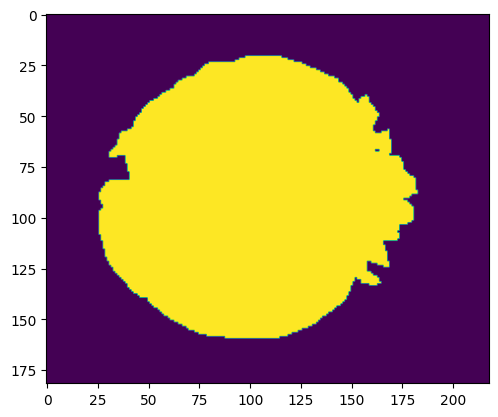

In [63]:
plt.imshow(mask[...,50])